--- SOLVER DA EQUAÇÃO DE BLASIUS ---

Iniciando convergência pelo Método do Tiro...
--------------------------------------------------
RESULTADOS NUMÉRICOS:
Valor convergido de f''(0) (s) : 0.332057
Erro final obtido              : 3.1734e-08
Número de iterações do Tiro    : 4
Valor alcançado de f'(eta_max) : 1.000000
--------------------------------------------------
ANÁLISE FÍSICA E COMPARATIVA:
f''(0) Numérico: 0.332057 | Literatura: 0.332057 | Erro rel: 0.0001%
eta_99 Numérico: 4.909988 | Literatura: 4.92 | Erro rel: 0.2035%
--------------------------------------------------
Resultados salvos em 'resultados_blasius.txt' para pós-processamento.

Feche a janela do gráfico para finalizar o programa.


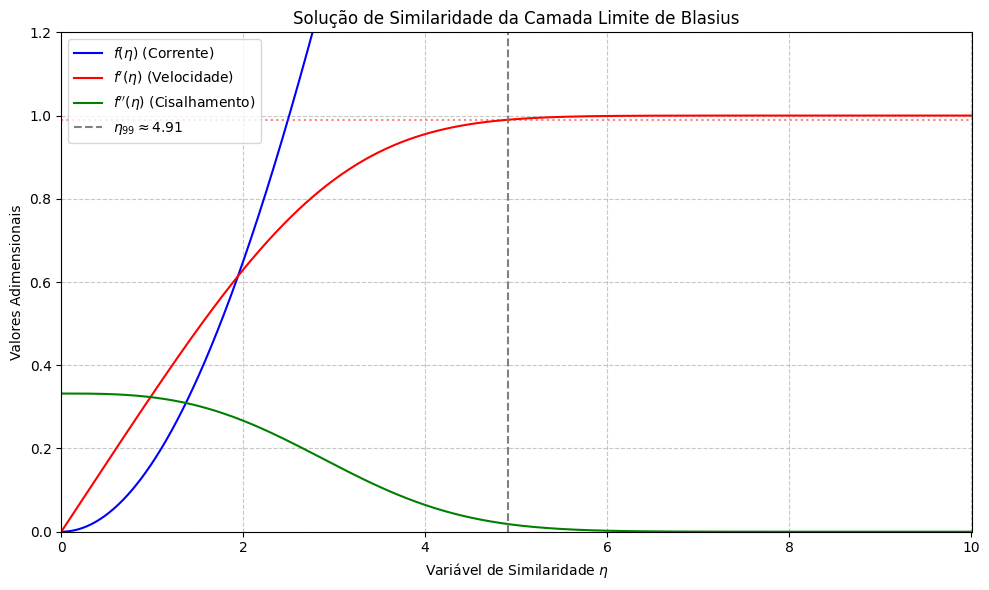

In [2]:
import math
import matplotlib.pyplot as plt

#rungekuta4

def blasius_edo(eta, y):
    """
    Define o sistema de EDOs de 1ª ordem da Equação de Blasius.
    y = [y1, y2, y3] correspondendo a [f, f', f'']
    Retorna as derivadas [y1', y2', y3']
    """
    dy1 = y[1]
    dy2 = y[2]
    dy3 = -0.5 * y[0] * y[2]
    return [dy1, dy2, dy3]

def rk4_passo(func, eta, y, h):
    """
    Avança um único passo h utilizando o método de Runge-Kutta de 4 Ordem.
    """
    # k1
    k1 = func(eta, y)
    y_k1 = [y[i] + 0.5 * h * k1[i] for i in range(3)]
    
    # k2
    k2 = func(eta + 0.5 * h, y_k1)
    y_k2 = [y[i] + 0.5 * h * k2[i] for i in range(3)]
    
    # k3
    k3 = func(eta + 0.5 * h, y_k2)
    y_k3 = [y[i] + h * k3[i] for i in range(3)]
    
    # k4
    k4 = func(eta + h, y_k3)
    
    # Atualização final
    y_novo = [y[i] + (h / 6.0) * (k1[i] + 2*k2[i] + 2*k3[i] + k4[i]) for i in range(3)]
    return y_novo

def resolver_pvi(s, eta_max, h):
    """
    Resolve o Problema de Valor Inicial do início ao fim da malha
    dado um chute s para f''(0).
    """
    eta_vals = [0.0]
    y_vals = [[0.0, 0.0, s]] # Condições iniciais: f(0)=0, f'(0)=0, f''(0)=s
    
    eta_atual = 0.0
    y_atual = y_vals[0]
    
    while eta_atual < eta_max:
        y_novo = rk4_passo(blasius_edo, eta_atual, y_atual, h)
        eta_atual += h
        
        eta_vals.append(eta_atual)
        y_vals.append(y_novo)
        y_atual = y_novo
        
    return eta_vals, y_vals


#METODO DO TIRO E FUNCAO ERRO (SECANTE)


def calcular_erro(s, eta_max, h):
    """
    Retorna o erro na fronteira: f'(eta_max) - 1
    """
    _, y_vals = resolver_pvi(s, eta_max, h)
    velocidade_no_infinito = y_vals[-1][1]
    return velocidade_no_infinito - 1.0

def metodo_do_tiro(s0, s1, eta_max, h, tol, max_iter):
    """
    Utiliza a Secante para encontrar o chute s que zera a funcao erro.
    """
    iteracao = 0
    e0 = calcular_erro(s0, eta_max, h)
    e1 = calcular_erro(s1, eta_max, h)
    
    while abs(e1) > tol and iteracao < max_iter:
        #Atualizacao do chute via Secante
        s_novo = s1 - e1 * (s1 - s0) / (e1 - e0)
        
        # Prepara variaveis para o proximo passo
        s0 = s1
        e0 = e1
        s1 = s_novo
        e1 = calcular_erro(s1, eta_max, h)
        
        iteracao += 1
        
    return s1, iteracao, e1


#INTERPOLAÇÃO PARA ESPESSURA DA CAMADA LIMITE


def encontrar_eta_99(eta_vals, y_vals):
    """
    Encontra a posicao eta onde f'(eta) atinge 0.99 via interpolacao linear simples.
    """
    for i in range(len(y_vals) - 1):
        f_linha_atual = y_vals[i][1]
        f_linha_prox = y_vals[i+1][1]
        
        # Verifica se o valor 0.99 esta entre este ponto e o proximo
        if f_linha_atual <= 0.99 and f_linha_prox >= 0.99:
            eta_atual = eta_vals[i]
            eta_prox = eta_vals[i+1]
            # Interpolação linear: y = mx + b
            inclinacao = (f_linha_prox - f_linha_atual) / (eta_prox - eta_atual)
            eta_99 = eta_atual + (0.99 - f_linha_atual) / inclinacao
            return eta_99
    return None



if __name__ == "__main__":
    print("--- SOLVER DA EQUAÇÃO DE BLASIUS ---\n")
    
    # Parametros solicitados pelo roteiro
    h = 0.01          # Passo de integração
    eta_max = 10.0    # Valor máximo de eta (infinito numérico)
    tol = 1e-6        # Tolerância de convergência
    max_iter = 100    # Número máximo de iterações do Tiro
    
    # Chutes iniciais arbitrarios para a Secante
    chute_inicial_0 = 0.1
    chute_inicial_1 = 0.5
    
    print("Iniciando convergência pelo Método do Tiro...")
    s_convergido, num_iters, erro_final = metodo_do_tiro(
        chute_inicial_0, chute_inicial_1, eta_max, h, tol, max_iter
    )
    
    # Calcula os perfis finais com o chute convergido
    eta_final, y_final = resolver_pvi(s_convergido, eta_max, h)
    
    # Extrai f, f' e f'' das matrizes
    f_vals = [y[0] for y in y_final]
    fl_vals = [y[1] for y in y_final]
    fll_vals = [y[2] for y in y_final]
    
    # Determina eta_99
    eta_99 = encontrar_eta_99(eta_final, y_final)
    
    # Comparativos Analíticos
    fll_0_classico = 0.332057
    eta_99_classico = 4.92
    
    # ------------------ SAÍDA NA TELA ------------------
    print("-" * 50)
    print("RESULTADOS NUMÉRICOS:")
    print(f"Valor convergido de f''(0) (s) : {s_convergido:.6f}")
    print(f"Erro final obtido              : {abs(erro_final):.4e}")
    print(f"Número de iterações do Tiro    : {num_iters}")
    print(f"Valor alcançado de f'(eta_max) : {fl_vals[-1]:.6f}")
    print("-" * 50)
    print("ANÁLISE FÍSICA E COMPARATIVA:")
    print(f"f''(0) Numérico: {s_convergido:.6f} | Literatura: {fll_0_classico} | Erro rel: {abs(s_convergido - fll_0_classico)/fll_0_classico * 100:.4f}%")
    if eta_99:
        print(f"eta_99 Numérico: {eta_99:.6f} | Literatura: {eta_99_classico} | Erro rel: {abs(eta_99 - eta_99_classico)/eta_99_classico * 100:.4f}%")
    print("-" * 50)
    
    # ------------------ EXPORTAÇÃO PARA ARQUIVO ------------------
    nome_arquivo = "resultados_blasius.txt"
    with open(nome_arquivo, "w") as file:
        file.write("eta, f, f_linha, f_duas_linhas\n")
        for i in range(len(eta_final)):
            file.write(f"{eta_final[i]:.4f}, {f_vals[i]:.6f}, {fl_vals[i]:.6f}, {fll_vals[i]:.6f}\n")
    print(f"Resultados salvos em '{nome_arquivo}' para pós-processamento.")
    
    # ------------------ PLOTAGEM DOS RESULTADOS ------------------
    plt.figure(figsize=(10, 6))
    plt.plot(eta_final, f_vals, label=r"$f(\eta)$ (Corrente)", color="blue")
    plt.plot(eta_final, fl_vals, label=r"$f'(\eta)$ (Velocidade)", color="red")
    plt.plot(eta_final, fll_vals, label=r"$f''(\eta)$ (Cisalhamento)", color="green")
    
    if eta_99:
        plt.axvline(x=eta_99, color='gray', linestyle='--', label=rf"$\eta_{{99}} \approx {eta_99:.2f}$")
        plt.axhline(y=0.99, color='red', linestyle=':', alpha=0.5)

    plt.title("Solução de Similaridade da Camada Limite de Blasius")
    plt.xlabel(r"Variável de Similaridade $\eta$")
    plt.ylabel("Valores Adimensionais")
    plt.xlim(0, max(eta_final))
    plt.ylim(0, 1.2) # Limita a visualização para os dados relevantes
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc="upper left")
    plt.tight_layout()
    
    print("\nFeche a janela do gráfico para finalizar o programa.")
    plt.show()
############
############
#https://github.com/josefelipe0036/CN-APLICADO/tree/main/ATIVIDADE_5